In [1]:
import xarray as xr
import numpy as np
from pathlib import Path

In [2]:
datadir = '/global/cfs/cdirs/m1867/zfeng/SCREAM-decadal/maps/'
imerg_landmask_file = f'{datadir}IMERG_land_sea_mask.nc'
tb_grid_file = f'{datadir}SCREAM_latlon_180W-180E_65S-65N.nc'

outfilename = f'{datadir}SCREAM_landmask_180W-180E_65S-65N.nc'
print(outfilename)

/global/cfs/cdirs/m1867/zfeng/SCREAM-decadal/maps/SCREAM_landmask_180W-180E_65S-65N.nc


In [3]:
dslm = xr.open_dataset(imerg_landmask_file)
dslm

<xarray.Dataset> Size: 26MB
Dimensions:      (lat: 1800, lon: 3602)
Coordinates:
  * lat          (lat) float64 14kB -89.95 -89.85 -89.75 ... 89.75 89.85 89.95
  * lon          (lon) float64 29kB -0.05 0.05 0.15 0.25 ... 359.9 360.0 360.1
Data variables:
    landseamask  (lat, lon) float32 26MB ...

In [4]:
dsin = xr.open_dataset(tb_grid_file)
dsin

<xarray.Dataset> Size: 75MB
Dimensions:    (lat: 1300, lon: 3600)
Coordinates:
  * lat        (lat) float64 10kB -64.95 -64.85 -64.75 ... 64.75 64.85 64.95
  * lon        (lon) float64 29kB -179.9 -179.9 -179.8 ... 179.8 179.9 179.9
Data variables:
    latitude   (lat, lon) float64 37MB ...
    longitude  (lat, lon) float64 37MB ...
Attributes: (12/16)
    Title:                     Cloudid file from 1995/02/01 00:00 UTC
    Institution:               Pacific Northwest National Laboratory
    Contact:                   Zhe Feng: zhe.feng@pnnl.gov
    Created_on:                Sat Jun  6 04:20:28 2026
    tb_threshold_core:         225.0
    tb_threshold_coldanvil:    241.0
    ...                        ...
    pf_smooth_window:          5
    pf_dbz_thresh:             3
    pf_link_area_thresh:       648.0
    pbc_direction:             x
    history:                   Sun Jun  7 14:27:56 2026: ncks -v lat,lon,lati...
    NCO:                       netCDF Operators version 5.3.9 (Homepage = htt...

In [5]:
# Crop the dataset to 65S-65N
dslm_c = dslm.sel(lon=slice(0,360), lat=slice(-65,65))
dsin_c = dsin.sel(lon=slice(-180,180), lat=slice(-65,65))

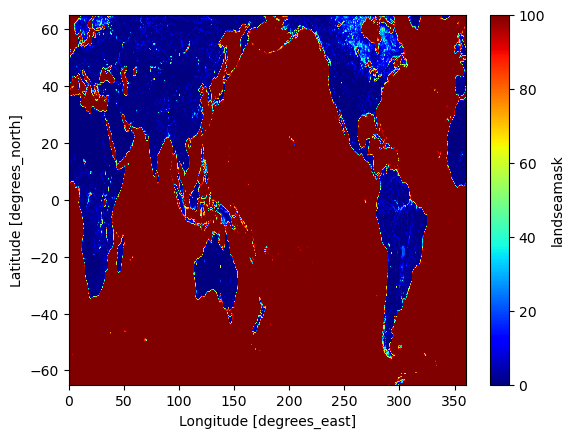

In [6]:
dslm_c.landseamask.plot(cmap='jet')

In [7]:
dslm_c.landseamask

<xarray.DataArray 'landseamask' (lat: 1300, lon: 3600)> Size: 19MB
[4680000 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 10kB -64.95 -64.85 -64.75 ... 64.75 64.85 64.95
  * lon      (lon) float64 29kB 0.05 0.15 0.25 0.35 ... 359.7 359.8 359.9 360.0

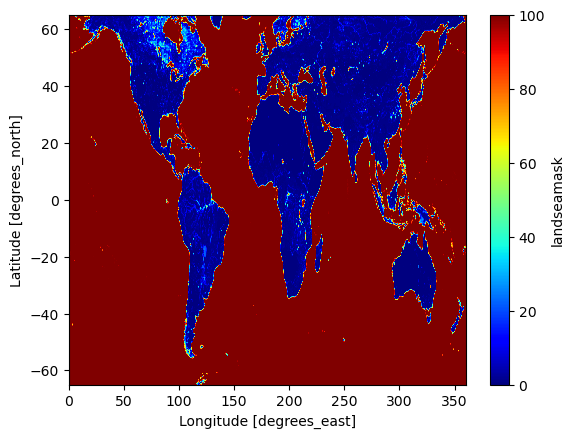

In [8]:
landseamask = dslm_c.landseamask.roll(lon=1800, roll_coords=False)
# dslm_c.landseamask.roll(lon=1800, roll_coords=False).plot(cmap='jet')
landseamask.plot(cmap='jet')

In [9]:
# # Get the full absolute path
# full_path = Path(__file__).resolve()
# print(f"Full path: {full_path}")

# Retrieves the filename directly from VS Code's system global variables
notebook_name = Path(globals()['__vsc_ipynb_file__']).name
print(notebook_name)

make_scream_landmask_65S-65N.ipynb


In [10]:
# Replace rolled landmask
dslm_c['landseamask'] = landseamask
# Replace landmask longitude (0~360) with the Tb grid's longitude (-180~+180)
dslm_c['lon'] = dsin_c['lon']
# Global attribute
dslm_c.attrs['produced_by'] = notebook_name

In [11]:
# Set encoding/compression for all variables
comp = dict(zlib=True, dtype='float32')
encoding = {var: comp for var in dslm_c.data_vars}

# Write to netcdf file
dslm_c.to_netcdf(path=outfilename, mode='w', format='NETCDF4', encoding=encoding)
print(f'Saved as: {outfilename}')

Saved as: /global/cfs/cdirs/m1867/zfeng/SCREAM-decadal/maps/SCREAM_landmask_180W-180E_65S-65N.nc
